In [1]:
import os, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Cố định seed để kết quả tái lập được
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

Device: cuda


## 1. Chuẩn bị Dữ liệu

In [2]:
import tensorflow_datasets as tfds
from PIL import Image as PILImage

DATA_ROOT = Path('./data/catdog')

if not (DATA_ROOT / 'train' / 'cat').exists():
    print('Đang tải cats_vs_dogs từ TFDS...')
    ds_splits, info = tfds.load(
        'cats_vs_dogs',
        split=['train[:80%]', 'train[80%:]'],
        as_supervised=True, with_info=True
    )
    for split_name, split_ds in zip(['train', 'val'], ds_splits):
        for cls in ['cat', 'dog']:
            (DATA_ROOT / split_name / cls).mkdir(parents=True, exist_ok=True)
        counts = {'cat': 0, 'dog': 0}
        for img_t, label in split_ds:
            cls = ['cat', 'dog'][label.numpy()]
            PILImage.fromarray(img_t.numpy()).save(
                str(DATA_ROOT / split_name / cls / f'{cls}_{counts[cls]:05d}.jpg')
            )
            counts[cls] += 1
        print(f'  {split_name}: {counts}')
    print('Tải xong!')
else:
    print('Dữ liệu đã có sẵn.')

Đang tải cats_vs_dogs từ TFDS...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

2026-03-20 18:02:03.159729: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774029723.563098      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774029723.680491      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774029724.571139      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774029724.571181      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774029724.571186      24 computation_placer.cc:177] computation placer alr

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HBRPOI_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
  train: {'cat': 9378, 'dog': 9232}
  val: {'cat': 2280, 'dog': 2372}
Tải xong!


## 2. Phân tích Dữ liệu


TRAIN:
  cat: 9378 ảnh
  dog: 9232 ảnh

VAL:
  cat: 2280 ảnh
  dog: 2372 ảnh


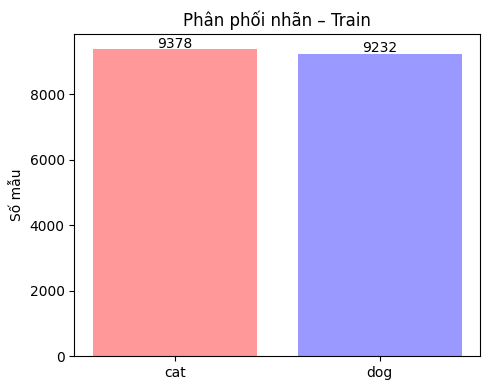

Width  – min:84, max:500, mean:415
Height – min:96, max:500, mean:374


In [3]:
# Đếm số mẫu
for split in ['train', 'val']:
    print(f'\n{split.upper()}:')
    for cls in ['cat', 'dog']:
        n = len(list((DATA_ROOT / split / cls).glob('*.jpg')))
        print(f'  {cls}: {n} ảnh')

# Biểu đồ cân bằng
train_cat = len(list((DATA_ROOT / 'train' / 'cat').glob('*.jpg')))
train_dog = len(list((DATA_ROOT / 'train' / 'dog').glob('*.jpg')))
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['cat', 'dog'], [train_cat, train_dog], color=['#FF9999', '#9999FF'])
ax.set_title('Phân phối nhãn – Train'); ax.set_ylabel('Số mẫu')
for i, v in enumerate([train_cat, train_dog]):
    ax.text(i, v + 50, str(v), ha='center')
plt.tight_layout(); plt.show()

# Phân tích kích thước ảnh
widths, heights = [], []
sample_paths = (list((DATA_ROOT / 'train' / 'cat').glob('*.jpg'))[:200] +
                list((DATA_ROOT / 'train' / 'dog').glob('*.jpg'))[:200])
for p in sample_paths:
    w, h = PILImage.open(p).size
    widths.append(w); heights.append(h)
print(f'Width  – min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}')
print(f'Height – min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}')

## 3. Augmentation & DataLoader

In [ ]:
IMG_SIZE = 160 

# Tính mean/std
_ds_tmp = ImageFolder(str(DATA_ROOT / 'train'),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()]))
_ld_tmp = DataLoader(_ds_tmp, batch_size=512, num_workers=2)
_m = torch.zeros(3); _s = torch.zeros(3)
for imgs, _ in _ld_tmp:
    _m += imgs.mean([0,2,3]); _s += imgs.std([0,2,3])
MEAN = (_m / len(_ld_tmp)).tolist()
STD  = (_s / len(_ld_tmp)).tolist()
print(f'Mean: {[round(v,4) for v in MEAN]}')
print(f'Std:  {[round(v,4) for v in STD]}')

Mean: [0.4797, 0.4551, 0.4078]
Std:  [0.259, 0.2524, 0.2552]


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = ImageFolder(str(DATA_ROOT / 'train'), transform=train_transform)
val_ds   = ImageFolder(str(DATA_ROOT / 'val'),   transform=val_transform)

# WeightedRandomSampler
label_counts   = Counter(train_ds.targets)
class_weights  = {k: 1.0 / v for k, v in label_counts.items()}
sample_weights = [class_weights[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=64,  sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False,   num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {train_ds.classes}')

Train: 18610 | Val: 4652
Classes: ['cat', 'dog']


## 4. MixUp Augmentation

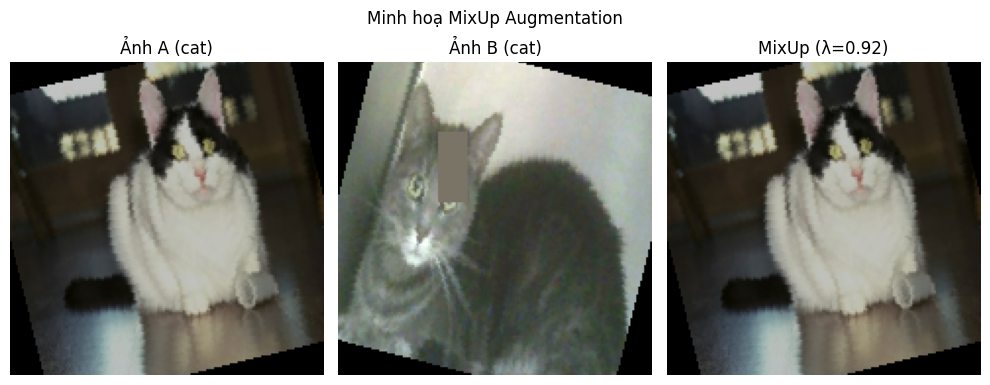

In [6]:
def mixup_data(x, y, alpha=0.4):
    """
    MixUp: trộn hai ảnh và hai nhãn theo tỷ lệ lambda ~ Beta(alpha, alpha).
    Giúp model học ranh giới quyết định mềm hơn, giảm overfit.
    """
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Minh hoạ MixUp
imgs_demo, labels_demo = next(iter(train_loader))
mixed, ya, yb, lam = mixup_data(imgs_demo[:2], labels_demo[:2], alpha=0.4)
mean_t = torch.tensor(MEAN).view(3,1,1); std_t = torch.tensor(STD).view(3,1,1)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, (img, title) in enumerate([
    (imgs_demo[0], f'Ảnh A ({train_ds.classes[ya[0]]})'),
    (imgs_demo[1], f'Ảnh B ({train_ds.classes[yb[1]]})'),
    (mixed[0],     f'MixUp (λ={lam:.2f})'),
]):
    show = (img.cpu() * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    axes[i].imshow(show); axes[i].set_title(title); axes[i].axis('off')
plt.suptitle('Minh hoạ MixUp Augmentation'); plt.tight_layout(); plt.show()

## 5. Xây dựng Mô hình CNN (5 khối)

In [7]:
class CatDog_CNN(nn.Module):
    """
    CNN 5 khối conv với BatchNorm + Dropout tăng dần + Global Average Pooling.
    Input: 3×160×160 → 2 lớp (cat / dog)
    Target: >90% validation accuracy.
    """
    def __init__(self, dropout_max=0.4):
        super().__init__()

        def conv_block(in_c, out_c, drop):
            return nn.Sequential(
                nn.Conv2d(in_c,  out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(drop),
            )

        # 160→80→40→20→10→5
        self.features = nn.Sequential(
            conv_block(3,   32,  drop=0.05),
            conv_block(32,  64,  drop=0.10),
            conv_block(64,  128, drop=0.20),
            conv_block(128, 256, drop=0.30),
            conv_block(256, 512, drop=dropout_max),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(dropout_max),
            nn.Linear(256, 2),
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


model = CatDog_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng params: {n_params:,}')
with torch.no_grad():
    out = model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device))
print(f'Output shape: {out.shape}  ✓')

Tổng params: 4,846,050
Output shape: torch.Size([2, 2])  ✓


## 6. Huấn luyện với MixUp + OneCycleLR

In [8]:
NUM_EPOCHS  = 50
USE_MIXUP   = True
MIXUP_ALPHA = 0.4

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-4,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos',
)

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    r_loss = correct = total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if USE_MIXUP and np.random.rand() < 0.5:   # MixUp 50% batch
            imgs, y_a, y_b, lam = mixup_data(imgs, labels, MIXUP_ALPHA)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam)
        else:
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        r_loss  += loss.item()
        _, pred  = out.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)

    t_loss = r_loss / len(train_loader)
    t_acc  = 100 * correct / total
    train_losses.append(t_loss); train_accs.append(t_acc)

    # ── Validate ──
    model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out    = model(imgs)
            v_loss += criterion(out, labels).item()
            _, pred = out.max(1)
            v_correct += pred.eq(labels).sum().item()
            v_total   += labels.size(0)

    v_loss /= len(val_loader)
    v_acc   = 100 * v_correct / v_total
    val_losses.append(v_loss); val_accs.append(v_acc)

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'best_catdog.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
              f'Train {t_loss:.4f}/{t_acc:.1f}% | '
              f'Val {v_loss:.4f}/{v_acc:.1f}%')

print(f'\n✅ Best Val Accuracy: {best_acc:.2f}%')

Epoch   1/50 | Train 0.9677/51.8% | Val 0.6600/61.6%
Epoch   5/50 | Train 0.6534/60.6% | Val 0.6036/70.4%
Epoch  10/50 | Train 0.5588/69.3% | Val 0.5044/77.5%
Epoch  15/50 | Train 0.5066/72.9% | Val 0.3764/86.5%
Epoch  20/50 | Train 0.4468/76.6% | Val 0.3109/90.5%
Epoch  25/50 | Train 0.4223/78.3% | Val 0.2836/91.7%
Epoch  30/50 | Train 0.3933/81.1% | Val 0.2522/93.6%
Epoch  35/50 | Train 0.3739/80.6% | Val 0.2410/94.3%
Epoch  40/50 | Train 0.3608/81.1% | Val 0.2236/95.0%
Epoch  45/50 | Train 0.3594/80.2% | Val 0.2212/94.9%
Epoch  50/50 | Train 0.3564/80.4% | Val 0.2207/95.1%

✅ Best Val Accuracy: 95.14%


## 7. Test-Time Augmentation (TTA)

In [9]:
def tta_predict(model, imgs, n_aug=5):
    """
    TTA: dự đoán trên ảnh gốc + n_aug lần flip/crop ngẫu nhiên,
    lấy trung bình xác suất → tăng độ chính xác.
    """
    tta_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(IMG_SIZE, padding=10),
    ])
    model.eval()
    probs_sum = torch.softmax(model(imgs), dim=1)
    for _ in range(n_aug - 1):
        aug_imgs = torch.stack([tta_transform(img) for img in imgs])
        with torch.no_grad():
            probs_sum += torch.softmax(model(aug_imgs.to(imgs.device)), dim=1)
    return probs_sum / n_aug

# Đánh giá với TTA
model.load_state_dict(torch.load('best_catdog.pth', map_location=device))
model.eval()

all_preds_tta, all_labels_tta = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        probs = tta_predict(model, imgs, n_aug=5)
        _, pred = probs.max(1)
        all_preds_tta.extend(pred.cpu().numpy())
        all_labels_tta.extend(labels.numpy())

tta_acc = 100 * np.mean(np.array(all_preds_tta) == np.array(all_labels_tta))
print(f'Val Accuracy (TTA x5): {tta_acc:.2f}%')
print(f'Val Accuracy (Best, no TTA): {best_acc:.2f}%')
print(f'Cải thiện từ TTA: +{tta_acc - best_acc:.2f}%')

Val Accuracy (TTA x5): 95.06%
Val Accuracy (Best, no TTA): 95.14%
Cải thiện từ TTA: +-0.09%


## 8. Trực quan & Đánh giá

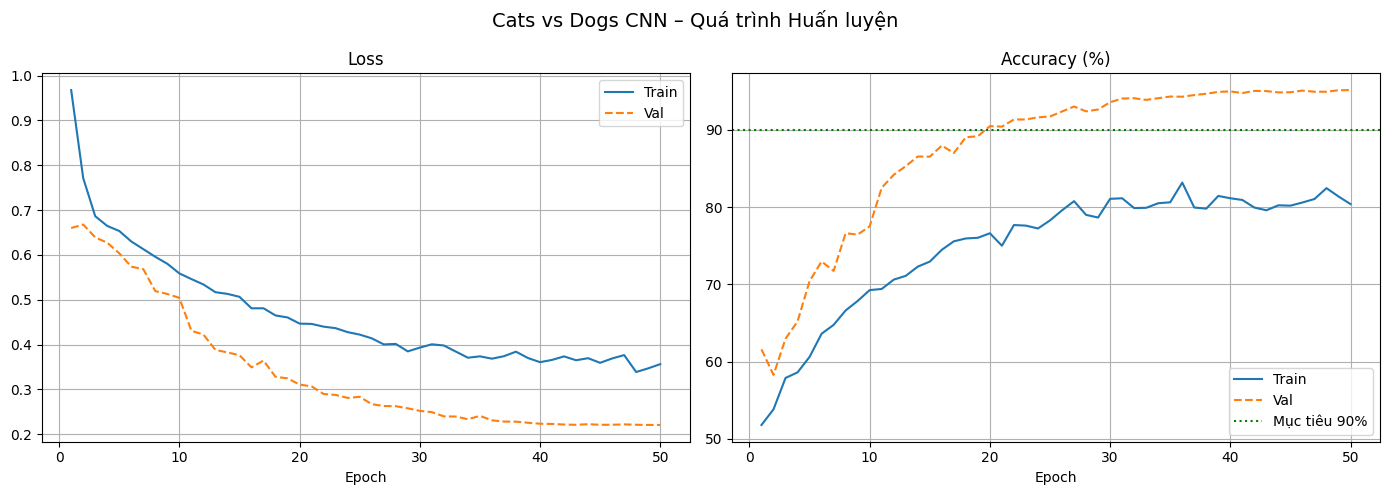

Train Acc cuối: 80.38%
Val   Acc cuối: 95.14%
Best  Val  Acc: 95.14%
Val   Acc (TTA): 95.06%
Gap: -14.76%


In [10]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, train_losses, label='Train'); axes[0].plot(epochs, val_losses, label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(epochs, train_accs, label='Train'); axes[1].plot(epochs, val_accs, label='Val', linestyle='--')
axes[1].axhline(90, color='green', linestyle=':', label='Mục tiêu 90%')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Cats vs Dogs CNN – Quá trình Huấn luyện', fontsize=14)
plt.tight_layout(); plt.show()

print(f'Train Acc cuối: {train_accs[-1]:.2f}%')
print(f'Val   Acc cuối: {val_accs[-1]:.2f}%')
print(f'Best  Val  Acc: {best_acc:.2f}%')
print(f'Val   Acc (TTA): {tta_acc:.2f}%')
print(f'Gap: {train_accs[-1] - val_accs[-1]:.2f}%')

              precision    recall  f1-score   support

         cat       0.96      0.93      0.95      2280
         dog       0.94      0.97      0.95      2372

    accuracy                           0.95      4652
   macro avg       0.95      0.95      0.95      4652
weighted avg       0.95      0.95      0.95      4652



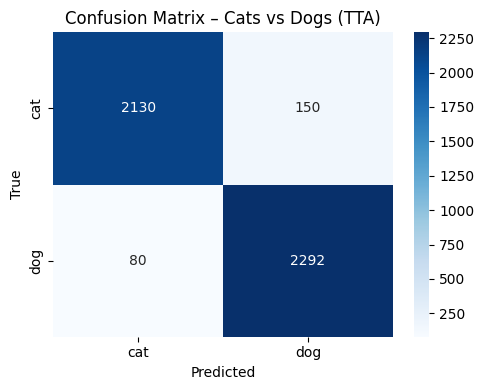

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(all_labels_tta, all_preds_tta, target_names=['cat', 'dog']))

cm = confusion_matrix(all_labels_tta, all_preds_tta)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['cat','dog'], yticklabels=['cat','dog'], ax=ax)
ax.set_title('Confusion Matrix – Cats vs Dogs (TTA)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

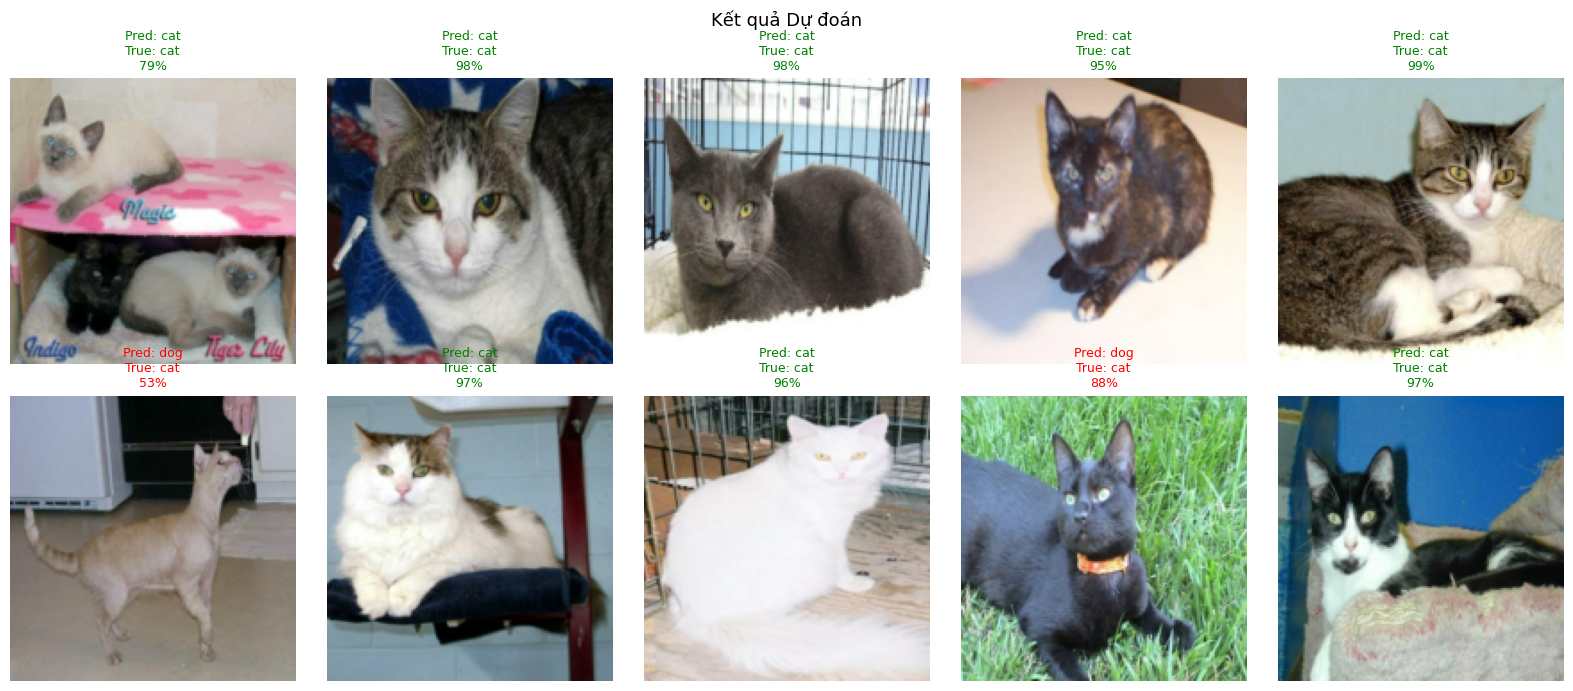

In [12]:
# Dự đoán mẫu
imgs_b, labels_b = next(iter(val_loader))
imgs_b = imgs_b.to(device)
mean_t = torch.tensor(MEAN).view(3,1,1); std_t = torch.tensor(STD).view(3,1,1)
with torch.no_grad():
    probs = torch.softmax(model(imgs_b), dim=1)
    confs, preds = probs.max(1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    img_show = (imgs_b[i].cpu() * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img_show)
    color = 'green' if preds[i].item() == labels_b[i].item() else 'red'
    ax.set_title(f'Pred: {["cat","dog"][preds[i]]}\nTrue: {["cat","dog"][labels_b[i]]}\n{confs[i]:.0%}',
                 color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Kết quả Dự đoán', fontsize=13); plt.tight_layout(); plt.show()